In [1]:
import os
import sys
import glob

import numpy as np
from cora.util import units

from draco.util import tools
from fitstack import containers

In [2]:
import getdist
from getdist import plots, MCSamples

Matplotlib created a temporary cache directory at /tmp/matplotlib-azf49izt because the default path (/home/h/halpern/arnab92/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib inline

In [4]:
from fitstack.chaintools import extract_priors, gdchain

In [5]:
from draco.core.containers import FrequencyStack, FrequencyStackByPol, MockFrequencyStack, FormedBeam
from fitstack.containers import MCMCFit1D

In [6]:
weight = ['inverse_var', 'uniform']
pol = 'xy'
param = ["transform_shot_noise_nonlinear_fixed","transform_shot_noise_nonlinear_free","transform_nonlinear_fixed"]

In [7]:
latex_names = {
    "offset": r"\Delta{\nu}",
    "omega": r"\Omega_{\rm HI}",
    "b_HI": r"b_{\rm HI}",
    "b_g": r"b_{\rm g}",
    "M_10": r"M_{10}",
    "NL": r"\alpha_{\rm NL}",
    "FoGh": r"\alpha_{\rm FoG,HI}",
    "FoGg": r"\alpha_{\rm FoG,g}",
}


In [8]:
fit = {}
for ww in weight:
    fit[ww] = {}
    for pp in param:
        path = f"/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/{pp}/{ww}/all/pol{pol}"
        print(path)
        fit_1D = MCMCFit1D.from_file(os.path.join(path,f"mcmc_fit_{pp}_joint_QSO_NGC.h5"))
        fit[ww][pp] = fit_1D
        
        # Extract the prior ranges from a MCMC fit chain 
        ranges = extract_priors(fit_1D)
        print(ranges)

        # Convert a CHIME MCMCFit object into something getdist can understand
        chain = gdchain(fit_1D, latex_names=latex_names, thin=20, ignore_rows=0.1, ranges=ranges)
        save_path = "/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/chains/"
        outname = save_path + f"chain_joint_QSO_{ww}_{pp}.gdchain"
        # chain.savePickle(str(outname))


/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/transform_shot_noise_nonlinear_fixed/inverse_var/all/polxy
{'offset': (-0.8, 0.8), 'omega': (-20.0, 20.0), 'omega_b_HI': (-20.0, 20.0), 'b_HI': (0.0, 10.0), 'M_10': (-500.0, 500.0)}
Removed 0.1 as burn in
/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/transform_shot_noise_nonlinear_free/inverse_var/all/polxy
{'offset': (-0.4, 0.4), 'omega': (-10.0, 10.0), 'b_HI': (0.0, 10.0), 'NL': (0.0, 5.0), 'FoGh': (0.0, 5.0), 'FoGg': (0.0, 5.0), 'M_10': (0.0, 20.0)}
Removed 0.1 as burn in
/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/transform_nonlinear_fixed/inverse_var/all/polxy
{'offset': (-0.8, 0.8), 'omega': (-20.0, 20.0), 'omega_b_HI': (-20.0, 20.0), 'b_HI': (0.0, 10.0)}
Removed 0.1 as burn in
/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/transform_shot_noise_nonlinear_fixed/uniform/all/polxy
{'offset': (-0.8, 0.8), 'omega': (-20.0, 20.0), 'omega

<Figure size 1000x1000 with 0 Axes>

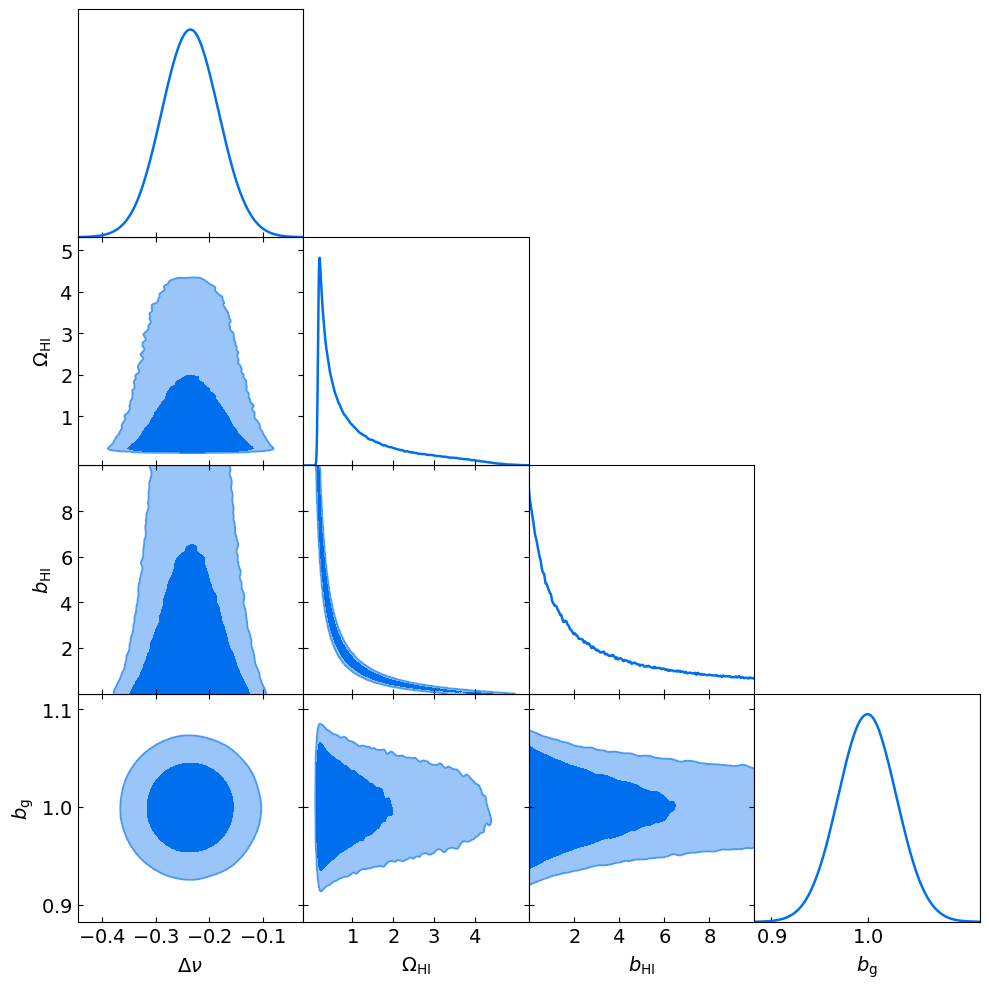

In [9]:
# Create plotter with larger size and better settings
g = plots.get_single_plotter(
    width_inch=10,           # Larger width for better readability
    scaling=True,
    ratio=1                  # Square aspect ratio
)

# Set additional GetDist-specific settings for publication quality
g.settings.axes_fontsize = 16        # Axis label font size
g.settings.lab_fontsize = 16         # Parameter label font size  
g.settings.legend_fontsize = 16      # Legend font size
#g.settings.colorbar_label_fontsize = 14
g.settings.title_limit_fontsize = 16

# Optional: Customize line widths and contour properties
g.settings.linewidth = 2.5           # Contour line width
g.settings.linewidth_contour = 2.0   # Filled contour edge width
g.settings.alpha_filled_add = 0.85   # Filled contour transparency

g.triangle_plot(
        [chain],
        
        filled=True,
        legend_loc=(0.6, 0.8),
        )